In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:41313")
client

<Client: 'tcp://127.0.0.1:41313' processes=8 threads=40, memory=157.35 GiB>

In [30]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import xrft
import s3fs
import gsw

import rioxarray

import glob

import gcm_filters

import seaborn as sns

import os.path as op

from scipy.interpolate import griddata, interpn

from xmovie import Movie

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.animation as animation
from matplotlib.animation import PillowWriter  # Import the GIF writer

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [4]:
grav = 9.807

sdir = '/tank/spectre/tuchida/SWOT/'
ddir = '/tank/spectre/tuchida/DMD/'

In [6]:
ds3t = xr.open_zarr(op.join(ddir,
            'SWOT/CalVal/mrCOSTS_h/MedSea/Pass003/geos_Pass003_tranchant-afterDMD.zarr' 
                            )
                   )
ds16t = xr.open_zarr(op.join(ddir,
            'SWOT/CalVal/mrCOSTS_h/MedSea/Pass016/geos_Pass016_tranchant-afterDMD.zarr' 
                            )
                   )
ds3t, ds16t

(<xarray.Dataset> Size: 125MB
 Dimensions:     (cycle_num: 98, num_lines: 372, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 784B 0 1 2 3 4 5 6 7 ... 91 92 93 94 95 96 97
   * num_lines   (num_lines) int64 3kB 0 1 2 3 4 5 6 ... 366 367 368 369 370 371
   * num_pixels  (num_pixels) int64 488B 0 1 2 3 4 5 6 7 ... 54 55 56 57 58 59 60
     latitude    (num_lines, num_pixels) float64 182kB dask.array<chunksize=(372, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 182kB dask.array<chunksize=(372, 61), meta=np.ndarray>
     time        (num_lines, num_pixels) datetime64[ns] 182kB dask.array<chunksize=(372, 61), meta=np.ndarray>
 Data variables:
     OW          (cycle_num, num_lines, num_pixels) float64 18MB dask.array<chunksize=(1, 372, 61), meta=np.ndarray>
     eta_fit     (cycle_num, num_lines, num_pixels) float64 18MB dask.array<chunksize=(1, 372, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 18MB dask.array<c

In [7]:
ke3 = np.sqrt(ds3t.ucg**2 + ds3t.vcg**2)
ke16 = np.sqrt(ds16t.ucg**2 + ds16t.vcg**2)

In [20]:
dsk = ke3.to_dataset(name="pass03")
dsk["pass16"] = ke16

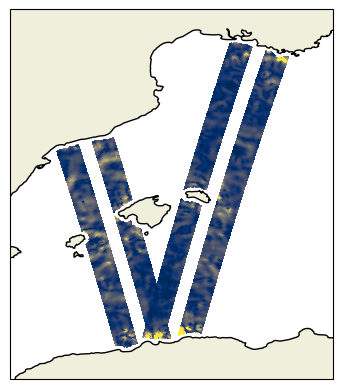

In [19]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
# ax = fig.subplots(ncols=1)
ax.set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())

ax.pcolormesh(ke16.longitude, ke16.latitude, ke16.isel(cycle_num=0), 
              cmap="cividis", vmin=0., vmax=.5)
ax.pcolormesh(ke3.longitude, ke3.latitude, ke3.isel(cycle_num=0), 
              cmap="cividis", vmin=0., vmax=.5)

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.set_aspect("equal")

/tank/spectre/tuchida/miniconda3/envs/dmd/lib/python3.11/site-packages/matplotlib/animation.py:892: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


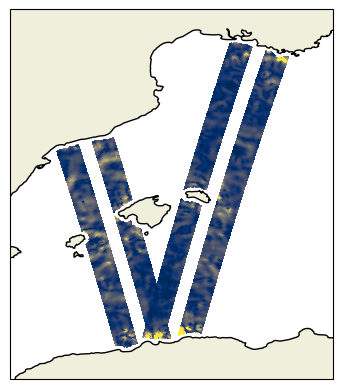

In [31]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
# ax = fig.subplots(ncols=1)
ax.set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.set_aspect("equal")

mesh1 = ax.pcolormesh(ke16.longitude, ke16.latitude, ke16.isel(cycle_num=0), 
                      cmap="cividis", vmin=0., vmax=.5)
mesh2 = ax.pcolormesh(ke3.longitude, ke3.latitude, ke3.isel(cycle_num=0), 
                      cmap="cividis", vmin=0., vmax=.5)

def update(frame):
    """
    This function is called for each frame in the animation.
    'frame' is the current frame number.
    """
    # Update the data array for the first dataset
    mesh1.set_array(ke16.isel(cycle_num=frame).values.flatten())
    # Update the data array for the second dataset
    mesh2.set_array(ke3.isel(cycle_num=frame).values.flatten())
    # Return the updated artists so the animation knows what has changed
    return (mesh1, mesh2,)

ani = animation.FuncAnimation(fig=fig, func=update, frames=98, interval=98)

ani.save(op.join(ddir,"MedSea-Speed.gif"), writer=PillowWriter(fps=10))

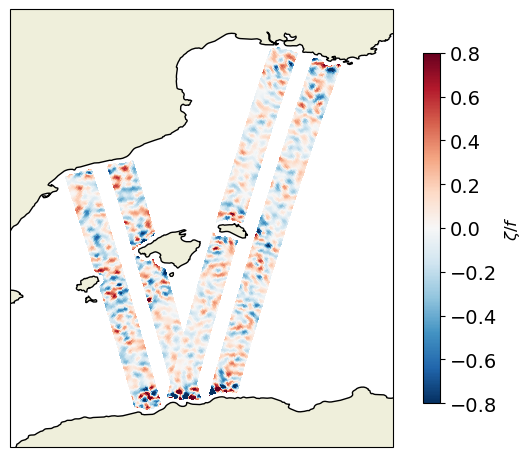

In [37]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
# ax = fig.subplots(ncols=1)
ax.set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.set_aspect("equal")

mesh1 = ax.pcolormesh(ds16t.longitude, ds16t.latitude, ds16t.vort.isel(cycle_num=0), 
                      cmap="RdBu_r", vmin=-.8, vmax=.8)
mesh2 = ax.pcolormesh(ds3t.longitude, ds3t.latitude, ds3t.vort.isel(cycle_num=0), 
                      cmap="RdBu_r", vmin=-.8, vmax=.8)

cbar = fig.colorbar(mesh1, ax=ax, shrink=.8)
cbar.set_label(r"$\zeta/f$", fontsize=12)

def update(frame):
    """
    This function is called for each frame in the animation.
    'frame' is the current frame number.
    """
    # Update the data array for the first dataset
    mesh1.set_array(ds16t.vort.isel(cycle_num=frame).values.flatten())
    # Update the data array for the second dataset
    mesh2.set_array(ds3t.vort.isel(cycle_num=frame).values.flatten())
    # Return the updated artists so the animation knows what has changed
    return (mesh1, mesh2,)

ani = animation.FuncAnimation(fig=fig, func=update, frames=98, interval=98)

ani.save(op.join(ddir,"MedSea-Ro.gif"), writer=PillowWriter(fps=10))